In [55]:
import os
import re
import nltk
from nltk import Tree

import spacy
#spacy.cli.download("en_core_web_sm")
# nlp = spacy.load("en_core_web_sm") 

import pandas as pd
import numpy as np

import textdescriptives as td

from dataset_evaluation.utils import add_column
from dataset_evaluation.evaluation_framework import EvaluationFramework

import folia.main as folia
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset

import pylangacq
import ast
from matplotlib.lines import Line2D

from vendi_score import text_utils

from diversity import (
	compression_ratio
)

import seaborn as sns
from matplotlib.patches import Patch
from datetime import datetime

plt.style.use("seaborn-v0_8-whitegrid")

## Load datasets

### Baseline

In [56]:
path = Path("/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/generated_stories_3/")

df_generated_stories = pd.concat(
	(pd.read_csv(file) for file in path.glob("stories_*.csv")),
	ignore_index=True
)

df_generated_stories.head()

,index,story
0,0,"Oei, ik vind dit allemaal heel grappig! Maar n..."
1,1,"Er was eens een meisje, een moeder en een hond..."
2,2,Er was eens een prins... (glimlach). Hij had e...
3,3,"Sorry, maar er zijn te veel verhalen om inspir..."
4,4,"Neem nou een olifant, maar niet zoals andere o..."


### ChiSCor

In [57]:
path_name = '/Users/sabijn/Documents/PhD/Datasets/chisor_dataset_all/ChiSCor_CoNLL_paper/csv/ChiSCor_master_df_password/ChiSCor_master_df.csv'
df_chiscor = pd.read_csv(path_name, index_col=0)
df_chiscor = df_chiscor.rename(columns={'story_raw': 'story'})

### Reference corpora

In [58]:
ref_standard_dep = Path('datasets/BasiScript/BS_dep_lexicon_unk_newlemmatizer.csv')
ref_standard_uni = Path('datasets/BasiScript/BS_unigram_lexicon.csv')
ref_standard_bi = Path('datasets/BasiScript/BS_bigram_lexicon.csv')

In [59]:
ref_spoken_b_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_bigram.csv')
ref_spoken_u_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_unigram.csv')
ref_spoken_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_trigram.csv')

## Additional cleaning

In [60]:
df_generated_stories["story"] = df_generated_stories["story"].str.replace(
	r"\s*\nEinde\.?\s*$",
	"",
	regex=True
)
df_generated_stories.iloc[0]['story']

'Oei, ik vind dit allemaal heel grappig! Maar nu vertel ik jou een verhaal.\n\nEr was eens een eend en zijn beste vriendin, een vogeltje. Ze waren op stap in het park. De eend zag een schattige vis in het water en zei: "Hé, kijk naar die leuke vis!" Het vogeltje vroeg: "Wil je hem wel even oppikken?" En de eend dacht: "Ja hoor, dat doe ik gewoon!"\n\nMaar toen pakte hij te hard aan, en de vis was heel klein. Hij ging zo snel als een flinke bal door het water schieten! De vogeltje lachte zo hard dat zij ook omviel van het lachen! En de eend dacht: "Zo\'n klein visje is vast niet erg gevaarlijk!" Maar toen zag hij die vis weer, en hij was nu GROOT!\n\nEn toen... TOEN EENTJE WAS DE VRIJDAG EN DE EEND HAD WAT TE DOEN!'

In [61]:
all_datasets = {'chiscor': df_chiscor}

## Story quality

Overview used metrics:
- Coherence
	- Local contextuality
- Grammaticality
	- Grammaticality
- Surprise
	- Creative perplexity
- Diversity
	- Lexical diversity: self-bleu
	- lexical diversity: moving mtld
- Complexity
	- Lexical complexity: unique words
	- Lexical complexity: Average word length
	- Syntactic complexity: avg. components
	- Syntactic complexity: dependency distance
	- Syntactic complexity: syntactic tree depth

In [62]:
eval_f = EvaluationFramework(language='nl',
							  pos_unigram=ref_spoken_u_csv, 
							  pos_bigram=ref_spoken_b_csv,
							  pos_trigram=ref_spoken_t_csv,
							  ref_unigram=ref_standard_uni,
							  ref_bigram=ref_standard_bi,
							  ref_ling_constrained=ref_standard_dep,
							  embedding_model='jegormeister/bert-base-dutch-cased')

In [66]:
# Surprise: creative perplexity
eval_f.add_pipe('creative_perplexity_dep')
# Local contextuality
# eval_f.add_pipe("local_contextuality")
# # Grammaticality
# eval_f.add_pipe('grammaticality')
# # Diversity (lexical) self-bleu
# eval_f.add_pipe('self-bleu')
# # Diversity (lexical) moving mtld
eval_f.add_pipe('lexical_diversity')
# # Complexity (lexical) unique words
# eval_f.add_pipe('unique-words')
# # Complexity (lexical) average word length
# eval_f.add_pipe('avg-word-length')
# # Complexity (syntactic)  average components
# eval_f.add_pipe('average_components')
# # Complexity (syntactic) dependency distance
# eval_f.add_pipe('dependency_distance')
# # Complexity (syntactic) syntactic tree depth
# eval_f.add_pipe('syntactic_depth')
# # Words before root
# eval_f.add_pipe('wbr_average')

In [67]:
def load_or_run_eval(eval_f, dataset, column, path_name, *, run=False):
	if Path(path_name).exists() and not run:
		df = pd.read_csv(path_name)
		if 'lexical_diversity' in df.columns:
			df['lexical_diversity'] = df['lexical_diversity'].apply(ast.literal_eval)
			
		return df

	dataset = eval_f.run_pipeline_on_df(dataset, column)
	dataset.to_csv(path_name, index=False)
	return dataset

In [68]:
def sample_and_run_eval(df, outdir, eval_f, n_runs, sample_size, column):
	run_summaries = []
	
	for run in tqdm(range(1, n_runs + 1)):
		seed = 1000 + run	# reproducible but different each run
		sample = df.sample(n=sample_size, replace=False, random_state=seed).copy()

		save_name = outdir / f'eval_results_new_dataset_run{run}_seed{seed}.csv'
		metrics_df = load_or_run_eval(eval_f, sample, column, save_name)

		metrics_df["lexical_diversity"] = metrics_df["lexical_diversity"].apply(lambda d: next(iter(d.values())))
		run_summary = metrics_df.mean(numeric_only=True).to_dict()
		run_summary["run"] = run
		run_summary["seed"] = seed

		run_summaries.append(run_summary)

	return run_summaries

def calculate_overall_statistics(run_summaries, out_dir):
	runs_df = pd.DataFrame(run_summaries).sort_values("run")
	runs_df_path = out_dir / "runs_summary.csv"
	runs_df.to_csv(runs_df_path, index=False)

	metric_cols = [c for c in runs_df.columns if c not in ["run", "seed"]]

	final_summary = pd.DataFrame({
		"metric": metric_cols,
		"mean_over_runs": [runs_df[c].mean() for c in metric_cols],
		"std_over_runs":  [runs_df[c].std(ddof=1) for c in metric_cols],  # sample std across runs
	})

	final_summary_path = out_dir / "final_mean_std.csv"
	final_summary.to_csv(final_summary_path, index=False)

	return final_summary

def new_dataset_eval(df, n_runs, sample_size, text_col, out_dir, eval_f):
	run_summaries = sample_and_run_eval(df, out_dir, eval_f, n_runs, sample_size, text_col)
	final_summary = calculate_overall_statistics(run_summaries, out_dir)

	return final_summary

def run_overall_dataset_statistics(df, outdir, n_runs, sample_size, column):
	dataset_run_rows = []

	for run in range(1, n_runs + 1):
		seed = 1000 + run
		sample = df.sample(n=sample_size, random_state=seed).copy()

		texts = list(map(str, sample[column].to_list()))

		# --- dataset-level metrics (one value per run) ---
		embed_vs = text_utils.embedding_vendi_score(
			texts, model_path="jegormeister/bert-base-dutch-cased"
		)
		comp_score = compression_ratio(texts, algorithm="gzip")

		dataset_run_rows.append({
			"run": run,
			"seed": seed,
			"vendi": embed_vs,
			"compression": comp_score,
		})

	dataset_runs_df = pd.DataFrame(dataset_run_rows)
	dataset_runs_df.to_csv(outdir / "dataset_metrics_runs.csv", index=False)
	
	return dataset_runs_df

# ----------------------------
# Config
# ----------------------------
n_runs = 5
sample_size = 600
text_col = "story"
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
out_dir = Path(f"results/new_dataset_results/{timestamp}")
out_dir.mkdir(parents=True, exist_ok=True)

final_summary = new_dataset_eval(df_generated_stories, n_runs, sample_size, text_col, out_dir, eval_f)
dataset_results = run_overall_dataset_statistics(df_generated_stories, out_dir, n_runs, sample_size, text_col)
print(final_summary)


  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
temp = all_datasets
for name, data in temp.items():
	print(f"Current method: {name}")
	generated_eval_results = load_or_run_eval(eval_f, data, 'story', f'results/metric_results_without_newlines/eval_results_{name}_new_cppl.csv')
	all_datasets[name] = generated_eval_results

Current method: chiscor


### Plotting story quality

In [ ]:
nice_name = {'creative_perplexity_dep': 'Creative perplexity',
			 'local_contextuality': 'Local contextuality',
			 'grammaticality': 'Grammaticality',
			 'self-bleu': 'Self-bleu',
			 'lexical_diversity': 'Moving MTLD',
			 'unique-words': 'Size of vocabulary',
			 'avg-word-length': 'Average word length',
			 'average_components': 'Average components',
			 'dependency_distance': 'Dependency distance',
			 'syntactic_depth': 'Syntactic depth'
			 }

In [ ]:
def get_value_from_dictionary(x, key):
	new = []

	for item in x:
		new.append(item[key])
	return new

In [ ]:
for name, data in all_datasets.items():
	print(data.columns)

Index(['id', 'story_lemmatized', 'story', 'story_raw_no_newlines', 'story_no',
       'chardepth', 'labels', 'labels_int', 'agegroup', 'treedepth_WNU',
       'compl_avg', 'wbr_avg', 'msTTR', 'maTTR', 'MTLD', 'MTLD_mov', 'MTLD_bi',
       'HDD', 'story_PP', 'dep_dist', 'agegroup_str',
       'creative_perplexity_dep', 'local_contextuality', 'grammaticality',
       'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length',
       'average_components', 'dependency_distance', 'syntactic_depth',
       'wbr_average'],
      dtype='object')


In [ ]:
metrics = ['creative_perplexity_dep', 'local_contextuality', 'grammaticality', 'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length', 'average_components', 'dependency_distance', 'syntactic_depth']
story_metrics_means = {}

for name in all_datasets.keys():
	story_metrics_means[name] = defaultdict(float)

for name, data in all_datasets.items():
	for column in data.columns:
		if column in metrics:
			try:
				story_metrics_means[name][column] = data[column].mean()
			except:
				x = get_value_from_dictionary(data[column], 'moving_mtld')
				story_metrics_means[name][column] = np.mean(np.array(x))
story_metrics_means


{'chiscor': defaultdict(float,
             {'creative_perplexity_dep': 695.8007185947558,
              'local_contextuality': 0.35675005582385594,
              'grammaticality': -2.151841574132531,
              'self-bleu': 0.1600734799389244,
              'lexical_diversity': 30.334225496690056,
              'unique-words': 58.49919224555735,
              'avg-word-length': 3.6996555194529486,
              'average_components': 0.2771282402314687,
              'dependency_distance': 2.6565392592136794,
              'syntactic_depth': 2.3651808887451864})}

In [ ]:
metrics = ['creative_perplexity_dep', 'local_contextuality', 'grammaticality', 'self-bleu', 'lexical_diversity', 'unique-words', 'avg-word-length', 'average_components', 'dependency_distance', 'syntactic_depth']
story_metrics_std = {}

for name in all_datasets.keys():
	story_metrics_std[name] = defaultdict(float)

for name, data in all_datasets.items():
	for column in data.columns:
		if column in metrics:
			try:
				story_metrics_std[name][column] = data[column].std()
			except:
				x = get_value_from_dictionary(data[column], 'moving_mtld')
				story_metrics_std[name][column] = np.std(np.array(x))
story_metrics_std



{'chiscor': defaultdict(float,
             {'creative_perplexity_dep': 6154.268893633569,
              'local_contextuality': 0.08943298319199602,
              'grammaticality': 0.10775946938845998,
              'self-bleu': 0.09677546171995319,
              'lexical_diversity': 9.11279918176435,
              'unique-words': 45.040268742625905,
              'avg-word-length': 0.29327328799667557,
              'average_components': 0.22394238696474542,
              'dependency_distance': 0.36507614789473675,
              'syntactic_depth': 0.4145999679686896})}

In [ ]:
df_story_means = pd.DataFrame.from_dict(story_metrics_means, orient="index")
df_story_means

,creative_perplexity_dep,local_contextuality,grammaticality,self-bleu,lexical_diversity,unique-words,avg-word-length,average_components,dependency_distance,syntactic_depth
chiscor,695.800719,0.35675,-2.151842,0.160073,30.334225,58.499192,3.699656,0.277128,2.656539,2.365181


(array([352., 133.,  49.,  21.,  17.,   8.,   5.,   5.,   4.,   2.]),
 array([   4.73194925,  187.3226498 ,  369.91335035,  552.50405089,
         735.09475144,  917.68545199, 1100.27615254, 1282.86685309,
        1465.45755363, 1648.04825418, 1830.63895473]),
 <BarContainer object of 10 artists>)

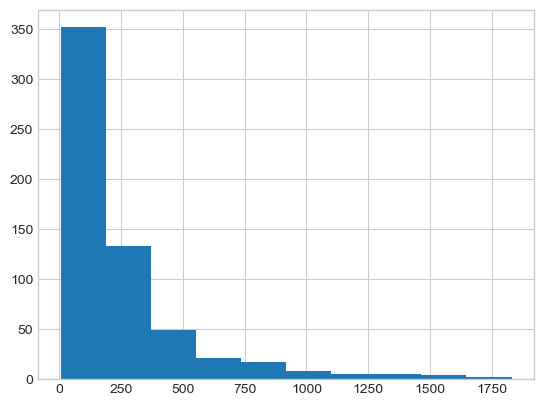

In [ ]:
plt.hist(all_datasets['chiscor']['creative_perplexity_dep'][all_datasets['chiscor']['creative_perplexity_dep'] < 2000])

In [ ]:
final_summary

,metric,mean_over_runs,std_over_runs
0,index,4884.905000,99.268577
1,creative_perplexity_dep,408.402478,31.547690
2,local_contextuality,0.308714,0.001114
3,grammaticality,-2.178633,0.003632
4,self-bleu,0.119220,0.003216
5,lexical_diversity,78.869514,0.741283
6,unique-words,88.733667,0.274665
7,avg-word-length,4.012899,0.005150
8,average_components,0.352568,0.005564
9,dependency_distance,2.941283,0.012827


In [ ]:
dataset_results['compression'].mean()

3.0101999999999998

## SimLex

In [ ]:
from gensim.models import Word2Vec
# from gensim.models.doc2vec import TaggedDocument
# from gensim.models import Doc2Vec
from sklearn.manifold import TSNE
from simplemma import text_lemmatizer
from adjustText import adjust_text

In [ ]:
simlex999 = pd.read_csv('dataset_evaluation/modelasametric/SimLex-999-Dutch-final.txt', names=['lemma1','lemma2','SimLexScore','POS'], skiprows=1, sep='\t')
simlex999.drop(index=364, inplace=True)

In [ ]:
from simplemma import text_lemmatizer
nlp = spacy.load("nl_core_news_lg") 

# function to clean raw stories
def lemmatize(data):
	sents = []
	for story in data:
		lines = list(nlp(story).sents)

		for sent in lines:
			words = []
			for w in sent:
				if w.is_alpha:
					try:
						lemma = text_lemmatizer(w.text.lower(), lang='nl')[0]
					except:
						lemma = w.lemma_.lower()
					words.append(lemma)
			sents.append(words)

	return sents

def train_and_save_w2v(data, save_name, mincount=10, callbacks=[]):
	if Path(save_name).exists():
		return Word2Vec.load(save_name)

	# list of sents of all stories
	sents = lemmatize(data)

	# train w2v
	model = Word2Vec(sents, 
						min_count=mincount, 
						window=5, 
						vector_size=100, 
						negative=5, 
						seed=42, 
						workers=1, 
						sg=0, 
						alpha=0.001, 
						epochs=500,
						callbacks=callbacks)
	
	model.save(save_name)

	return model

In [ ]:
def compute_similarity(lemma_list, model):
	pairs = lemma_list
	cos_sim = []

	for pair in pairs:
		cos_sim.append(model.wv.similarity(pair[0], pair[1]))

	return cos_sim

In [ ]:
def select_invocab_simlex(simlex: pd.DataFrame, models: Word2Vec, sample=None):
	vocab_sets = [set(model.wv.key_to_index) for model in models]
	shared_vocab = set.intersection(*vocab_sets)

	in_vocab_simlex = simlex[
		simlex["lemma1"].isin(shared_vocab) &
		simlex["lemma2"].isin(shared_vocab)
	]

	if sample:
		in_vocab_simlex = in_vocab_simlex.sample(sample)
		
	# Outputs
	word_list = list(set(in_vocab_simlex["lemma1"]).union(in_vocab_simlex["lemma2"]))
	word_pairs = list(in_vocab_simlex[["lemma1", "lemma2"]].itertuples(index=False, name=None))

	return in_vocab_simlex, word_list, word_pairs

In [ ]:
from itertools import combinations
from scipy.stats import spearmanr

def pairwise_spearman(sim_lists):
	"""
	sim_lists: list of 1D arrays/lists, one per model.
			   e.g. [sims_model1, sims_model2, sims_model3, ...]
	
	Returns: dict with ((i, j) -> spearman_r)
	"""
	results = {}
	names = list(sim_lists.keys())
	similarities = list(sim_lists.values())

	for i, j in combinations(range(len(similarities)), 2):
		r, p = spearmanr(similarities[i], similarities[j])
		results[(names[i], names[j])] = {"rho": r, "p": p}

	return results

In [ ]:
from typing import List

def create_tsne_projections(model, lemmas: List, *, plotting=True, title=None, use_pretrained=False):
	vocab = list(model.wv.key_to_index)

	if use_pretrained:
		X = []
		for w in vocab:
			X.append(nlp(w).vector)
		X = np.array(X)
	else:
		X = model.wv[vocab]

	tsne = TSNE(n_components=2, random_state=42, perplexity=5)
	X_tsne = tsne.fit_transform(X)

	df_tsne = pd.DataFrame(X_tsne, index=vocab, columns=['x', 'y'])
	df_tsne = df_tsne.loc[lemmas]

	if plotting:
		fig, ax = plt.subplots(figsize=(10, 4))
		sns.regplot(x='x', y='y', data=df_tsne, scatter=True, fit_reg=False, x_jitter=0.4, y_jitter=0.4)
		ax.set(xlabel='', ylabel='')
		ax.tick_params(left=True,
						bottom=True,
						labelleft=False,
						labelbottom=False)
		ax.set_title(title)

		texts = []
		for x, y, word in zip(df_tsne['x'], df_tsne['y'], df_tsne.index):
			text = plt.text(x, y, word)
			texts.append(text)

		adjust_text(texts)

In [ ]:
# Check creative perplexity distribution 

In [ ]:
# initialise word2vec model
mincount = 10
trained_models = {}
n_runs = 5
sample_size = 600

for run in tqdm(range(1, n_runs + 1)):
	seed = 1000 + run	# reproducible but different each run
	sample = df_generated_stories.sample(n=sample_size, replace=False, random_state=seed).copy()

	model = train_and_save_w2v(sample['story'], f'dataset_evaluation/modelasametric/new_dataset/story_Word2Vec_run{run}_seed{seed}.kv', mincount=mincount)
	trained_models[f'{run}_{seed}'] = model

  0%|          | 0/5 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


45
45
45
45
45


{('1_1001', 'simlex'): {'rho': 0.3709438315305582, 'p': 0.012122611177681953},
 ('2_1002', 'simlex'): {'rho': 0.3299186404503976, 'p': 0.026879679778294172},
 ('3_1003', 'simlex'): {'rho': 0.3225615181115658, 'p': 0.030691491118574717},
 ('4_1004', 'simlex'): {'rho': 0.3616180256875806, 'p': 0.014655788780803713},
 ('5_1005', 'simlex'): {'rho': 0.23598207865680518, 'p': 0.11861776336681996}}

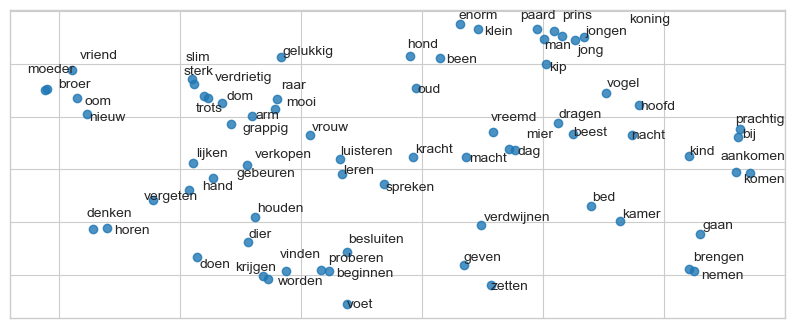

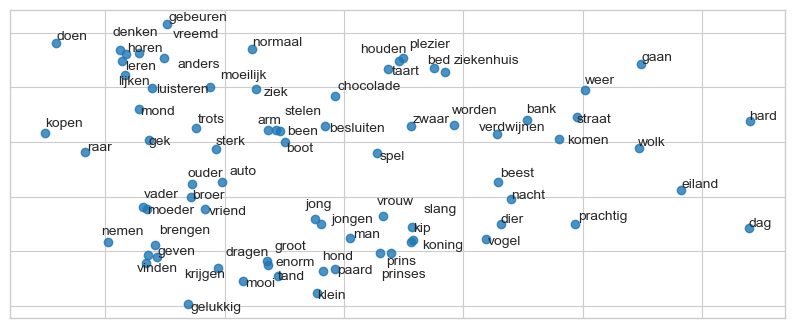

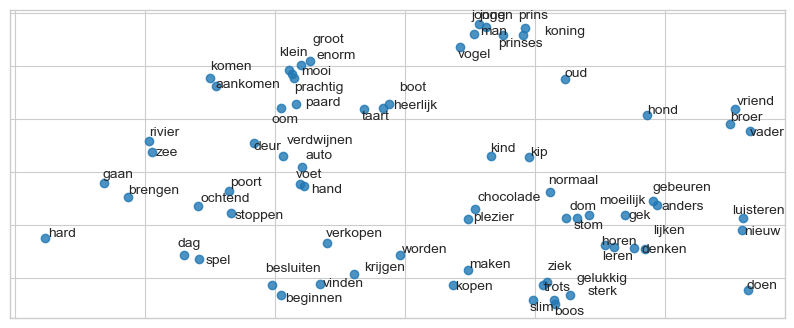

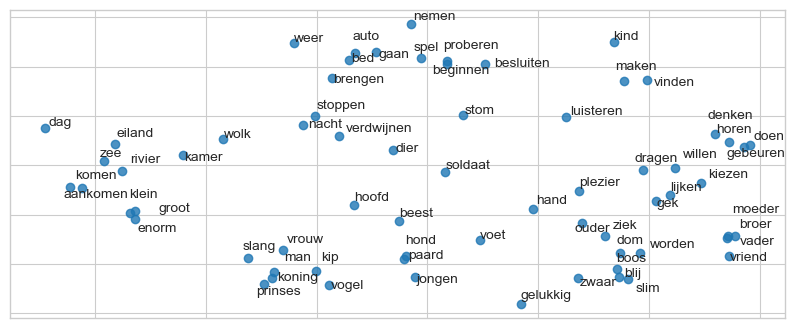

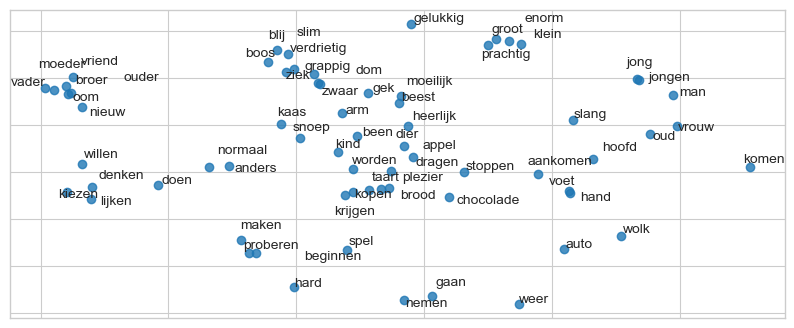

In [ ]:
cosine_similarities = {}
chosen_lemmas = {}
results = {}
amount_of_words = defaultdict(list)

for name, model in trained_models.items():
	df_filtered_simlex, filtered_simlex_list, filtered_simlex_tuple = select_invocab_simlex(simlex999, [model], sample=45)
	create_tsne_projections(model, filtered_simlex_list)
	chosen_lemmas[name] = df_filtered_simlex
	cosine_similarities[name] = compute_similarity(filtered_simlex_tuple, model)
	r, p = spearmanr(cosine_similarities[name], df_filtered_simlex['SimLexScore'])
	print(len(chosen_lemmas[name]))
	results[(name, 'simlex')] = {"rho": r, "p": p}

	for (lemma1, lemma2) in filtered_simlex_tuple:
		amount_of_words[name].extend([model.wv.get_vecattr(lemma1, "count"), model.wv.get_vecattr(lemma2, "count")])
results

In [ ]:
all = []
for value in results.values():
    all.append(value['rho'])
print(sum(all) / len(all))

0.32420481888738145


## Radar plot

In [ ]:
rename_dict = {
    "creative_perplexity_dep": "Creative PPL.",
    "local_contextuality": "Local Contextuality",
    "grammaticality": "Grammaticality",
    "self-bleu": "Self-BLEU",
    "lexical_diversity": "Moving MTLD",
    "unique-words": "Amount of Unique Words",
    "avg-word-length": "Average Word Length",
    "average_components": "Average Components",
    "dependency_distance": "Dependency Distance",
    "syntactic_depth": "Syntactic Tree Depth",
}

higher_is_better = {
    "creative_perplexity_dep": True,
    "local_contextuality": True,
    "grammaticality": True,
    "self-bleu": False,
    "lexical_diversity": True,
    "unique-words": True,
    "avg-word-length": True,
    "average_components": True,
    "dependency_distance": True,
    "syntactic_depth": True,
}

In [ ]:
def radar_relative_change(
    df: pd.DataFrame,
    baseline: str,
    model: str,
    metric_rename: dict[str, str] | None = None,
    higher_is_better: dict[str, bool] | None = None,
    cap: float = 0.5,           # cap relative change at ±50%
    figsize=(7, 7),
    title: str | None = None,
    baseline_label: str | None = None,
    model_label: str | None = None,
):
    """
    df: rows=models, cols=metrics (raw values)
    baseline: index label of baseline row
    model: index label of model to compare
    """

    df_plot = df.copy()

    # Rename metrics early
    if metric_rename:
        df_plot = df_plot.rename(columns=metric_rename)

    # Extract rows
    base = df_plot.loc[baseline]
    mod = df_plot.loc[model]

    # Direction handling: ensure higher = better
    if higher_is_better:
        for m, hib in higher_is_better.items():
            m2 = metric_rename.get(m, m) if metric_rename else m
            if m2 in df_plot.columns and hib is False:
                base[m2] = -base[m2]
                mod[m2] = -mod[m2]

    # Relative change
    rel = (mod - base) / base.abs()

    # Clip extreme values
    rel = rel.clip(-cap, cap)

    # Map [-cap, cap] → [0, 1] for plotting
    values = (rel + cap) / (2 * cap)

    metrics = list(values.index)
    n = len(metrics)

    if n < 3:
        raise ValueError("Radar plots need at least 3 metrics.")

    # Angles
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    # Close the loop
    plot_values = values.tolist()
    plot_values += plot_values[:1]

    # Baseline reference ring at 0.5
    baseline_ring = [0.5] * (n + 1)

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([f"-{cap * 100}%", "", "", "", f"+{cap * 100}%"])

    # Baseline ring
    ax.plot(angles, baseline_ring, linestyle="--", linewidth=2, color="tab:blue", label=baseline_label)
    ax.fill(angles, baseline_ring, alpha=0.15, color="tab:blue")

    # Model
    ax.plot(angles, plot_values, linewidth=2, label=model_label, color="tab:orange")
    ax.fill(angles, plot_values, alpha=0.15, color="tab:orange")

    if title:
        ax.set_title(title, pad=20)
    
    ax.tick_params(axis='both', which='major', labelsize=12)

    # # Remove radial grid lines (including outer circle)
    # ax.yaxis.grid(False)

    # Remove the polar spine (outer circle)
    ax.spines["polar"].set_visible(False)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10), frameon=False, fontsize=12)
    plt.tight_layout()
    plt.savefig('results/paper_plots/newdataset_radar_plots.pdf')


In [ ]:
df_story_means

,creative_perplexity_dep,local_contextuality,grammaticality,self-bleu,lexical_diversity,unique-words,avg-word-length,average_components,dependency_distance,syntactic_depth
chiscor,695.800719,0.35675,-2.151842,0.160073,30.334225,58.499192,3.699656,0.277128,2.656539,2.365181


In [ ]:
df_transformed = (
    final_summary
    .set_index("metric")                 # make metric the index
    .rename_axis(None, axis=0) 
    .drop(columns=["std_over_runs"])      # drop std_over_runs
    .rename(columns={"mean_over_runs": "own_dataset"})
    .T                                   # transpose
)
df_transformed = df_transformed.drop(columns=["wbr_average", "index"])


In [ ]:
df_combined = pd.concat([df_transformed, df_story_means], axis=0)


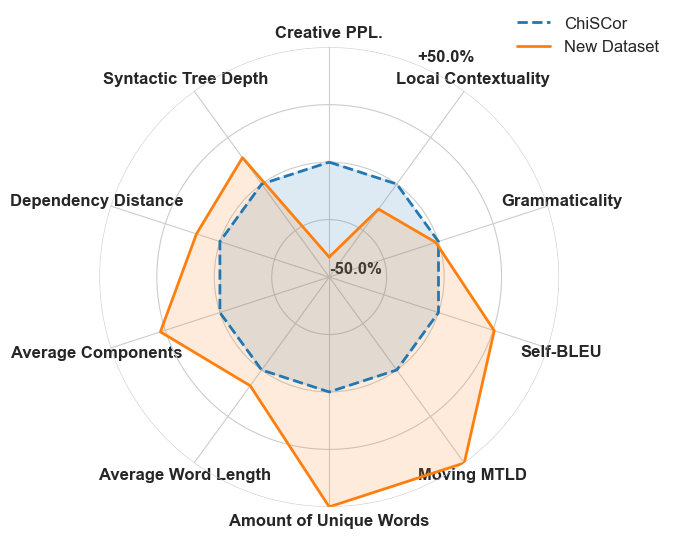

In [ ]:
radar_relative_change(
    df_combined,
    baseline="chiscor",
    model="own_dataset",
    metric_rename=rename_dict,
    higher_is_better=higher_is_better,
    cap=0.5,
    baseline_label='ChiSCor',
    model_label='New Dataset'
)

In [ ]:
sample = df_generated_stories.sample(n=600, replace=False).copy()

In [ ]:
c_ppl = sample.apply(lambda row: eval_f.run_component('creative_perplexity_dep', row['story']), axis=1)

In [ ]:
type(c_ppl)

pandas.core.series.Series

(array([528.,  54.,  11.,   3.,   2.,   0.,   1.,   0.,   0.,   1.]),
 array([  28.14715213,  785.91785181, 1543.68855149, 2301.45925117,
        3059.22995085, 3817.00065053, 4574.77135021, 5332.54204988,
        6090.31274956, 6848.08344924, 7605.85414892]),
 <BarContainer object of 10 artists>)

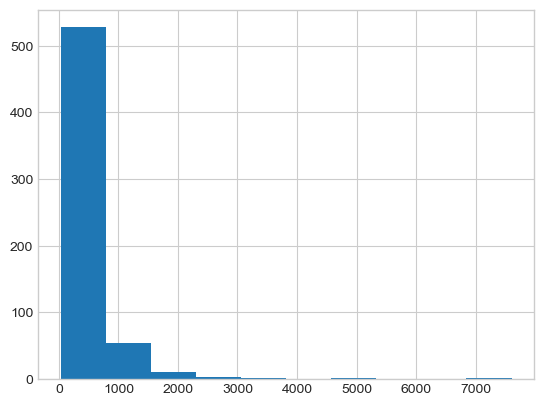

In [ ]:
plt.hist(c_ppl)

In [ ]:
print(c_ppl.mean())
print(c_ppl.std())

424.635701517232
541.464864641785


In [ ]:
all_datasets['chiscor'][all_datasets['chiscor']['creative_perplexity_dep'] == all_datasets['chiscor']['creative_perplexity_dep'].max()]

,id,story_lemmatized,story,story_raw_no_newlines,story_no,chardepth,labels,labels_int,agegroup,treedepth_WNU,...,local_contextuality,grammaticality,self-bleu,lexical_diversity,unique-words,avg-word-length,average_components,dependency_distance,syntactic_depth,wbr_average
478,91001,ik mag altijd bij mijn oma op bed spelen,ik mag altijd bij mijn oma op bed spelen.\n,ik mag altijd bij mijn oma op bed spelen.,1,3,agent,2,3,2.0,...,0.0,-2.017707,0.0,{'moving_mtld': 14.0},10,3.3,0.0,3.333333,2.0,8.0


In [ ]:
print(all_datasets['chiscor']['creative_perplexity_dep'].mean())
print(all_datasets['chiscor']['creative_perplexity_dep'].std())

695.8007185947558
6154.268893633569


(array([352., 133.,  49.,  21.,  17.,   8.,   5.,   5.,   4.,   2.]),
 array([   4.73194925,  187.3226498 ,  369.91335035,  552.50405089,
         735.09475144,  917.68545199, 1100.27615254, 1282.86685309,
        1465.45755363, 1648.04825418, 1830.63895473]),
 <BarContainer object of 10 artists>)

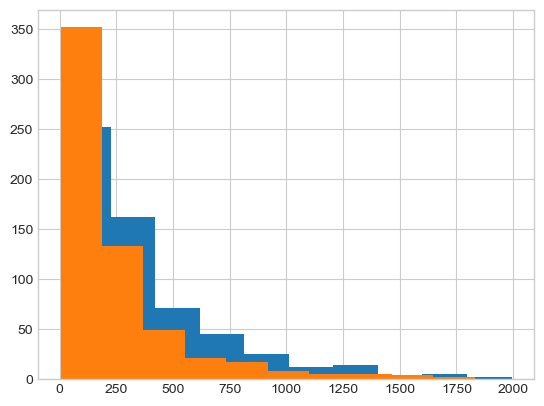

In [ ]:
plt.hist(c_ppl[c_ppl < 2000])
plt.hist(all_datasets['chiscor']['creative_perplexity_dep'][all_datasets['chiscor']['creative_perplexity_dep'] < 2000])